# Load necessary files

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

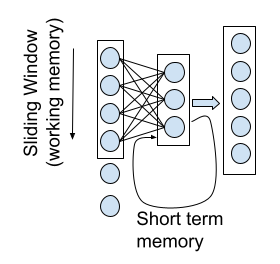

In [2]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, len(tokens))
        #self.fc2 = nn.Linear(len(tokens), len(tokens))
        
    def forward(self, x, h0=None, return_state_only = False):
        if h0 == None:
            out, h0 = self.rnn(x)
        else:   
            out, h0 = self.rnn(x, h0)
        #out = torch.nn.functional.relu(self.fc1(out[0]))
        # print(out.shape)

        if return_state_only:
            return out, h0
            
        out = self.fc1(out[:,-1,:])
        # out = torch.nn.functional.softmax(out, dim=2)
        return out, h0

In [3]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [4]:
class Dataset_converter_compressed(Dataset):
    def __init__(self, data, dropping_proba=0.1, first_training=2000, compressed_training=2000, working_memory=1, short_term_memory=8):
        data_ = ''

        samples_per_slot = 20
        slots = compressed_training//samples_per_slot

        drop = []
        for ii in range(slots+1):
            if ii%2:
                drop_p = bernoulli.rvs(size=compressed_training, p=1-dropping_proba)
            else:
                drop_p = bernoulli.rvs(size=compressed_training, p=1)
                
            drop.extend(drop_p)
        np.random.shuffle(drop)
        # print(drop[:1000])
        
        for ii, ch in enumerate(data):
            if ii>=first_training and ii<first_training+compressed_training:
                if drop[ii-first_training]:
                    data_ += ch
            else:
                data_ += ch
                
        one_hot_encoded = np.zeros((len(data_), len(tokens)), dtype=int)
        for ii, token in enumerate(data_):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data_)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data_)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

# Load dataset

In [5]:
data = pd.read_csv("../Seq_500000.txt")['seq'][0]

In [216]:
def experiment(working_memory, short_term_memory, hidden_size=20, num_layers=1, reps=5, lr=1e-3, prev_mem=False):
    test_acc_rnn = np.zeros((reps, len(data)-1), dtype=float)
    data_set = Dataset_converter(data, working_memory, short_term_memory)
    
    for rep in tqdm(range(reps)):
        torch.manual_seed(rep)
        model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
        
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = torch.nn.CrossEntropyLoss()
    
        total = 0
        correct = np.zeros(1000,dtype=float)
        for X, y in train_loader:
            optimizer.zero_grad()
    
            if total==0:
                    # print(hidden_memory.shape)
                predicted_y, _ = model(X)
            elif prev_mem:
                    
                predicted_y, _ = model(X, mem)
            else:
                predicted_y, _ = model(X)

            # print(predicted_y.shape, y.shape)
            loss = criterion(predicted_y, y)
            loss.backward()
    
            optimizer.step()
    
            with torch.no_grad():
                
                if prev_mem:
                     _, mem = model(X[:1,:1,:], return_state_only=True)
    
                true_y = y.argmax(axis=1)
                estimated_y = predicted_y.argmax(axis=1)

                if true_y == estimated_y:
                        correct[total%1000] = 1
                else:
                    correct[total%1000] = 0

                total += 1
                test_acc_rnn[rep,total] = np.sum(correct)/total if total<1000 else np.sum(correct)/1000
                
                    
    
                # if total%10000 == 0:
                #     print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc_rnn[rep,total-1]:.4f}')

                
    return test_acc_rnn

In [217]:
working_memory = 1
short_term_memories = np.arange(1,9,1)
test_acc_without_mem = []
test_acc_with_mem = []

print('Doing without initializing h0')
for short_term_memory in short_term_memories:
    print(f'Working memory : {working_memory}, short term memory : {short_term_memory}')
    
    test_acc_without_mem.append(
        experiment(working_memory, short_term_memory)
    )


print('Doing with initializing h0')
for short_term_memory in short_term_memories:
    print(f'Working memory : {working_memory}, short term memory : {short_term_memory}')
    
    test_acc_with_mem.append(
        experiment(working_memory, short_term_memory, prev_mem=True)
    )

Doing without initializing h0
Working memory : 1, short term memory : 1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:08<00:00, 25.73s/it]


Working memory : 1, short term memory : 2


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:23<00:00, 28.79s/it]


Working memory : 1, short term memory : 3


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [03:42<00:00, 44.44s/it]


Working memory : 1, short term memory : 7


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [03:53<00:00, 46.77s/it]


Working memory : 1, short term memory : 8


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:11<00:00, 50.29s/it]


# Show the color palette (left colors indicate lower working memory)

In [138]:
sns.color_palette("icefire", n_colors=len(short_term_memories))

[(0.42110294, 0.69916972, 0.80506683),
 (0.2157176, 0.47827123, 0.81487615),
 (0.2659204, 0.25949691, 0.511417),
 (0.14254381, 0.14016944, 0.18944326),
 (0.19884415, 0.12394381, 0.1385669),
 (0.47151732, 0.17401641, 0.24610337),
 (0.78979746, 0.24694858, 0.22678822),
 (0.93850535, 0.52748892, 0.28242464)]

# Plot the result

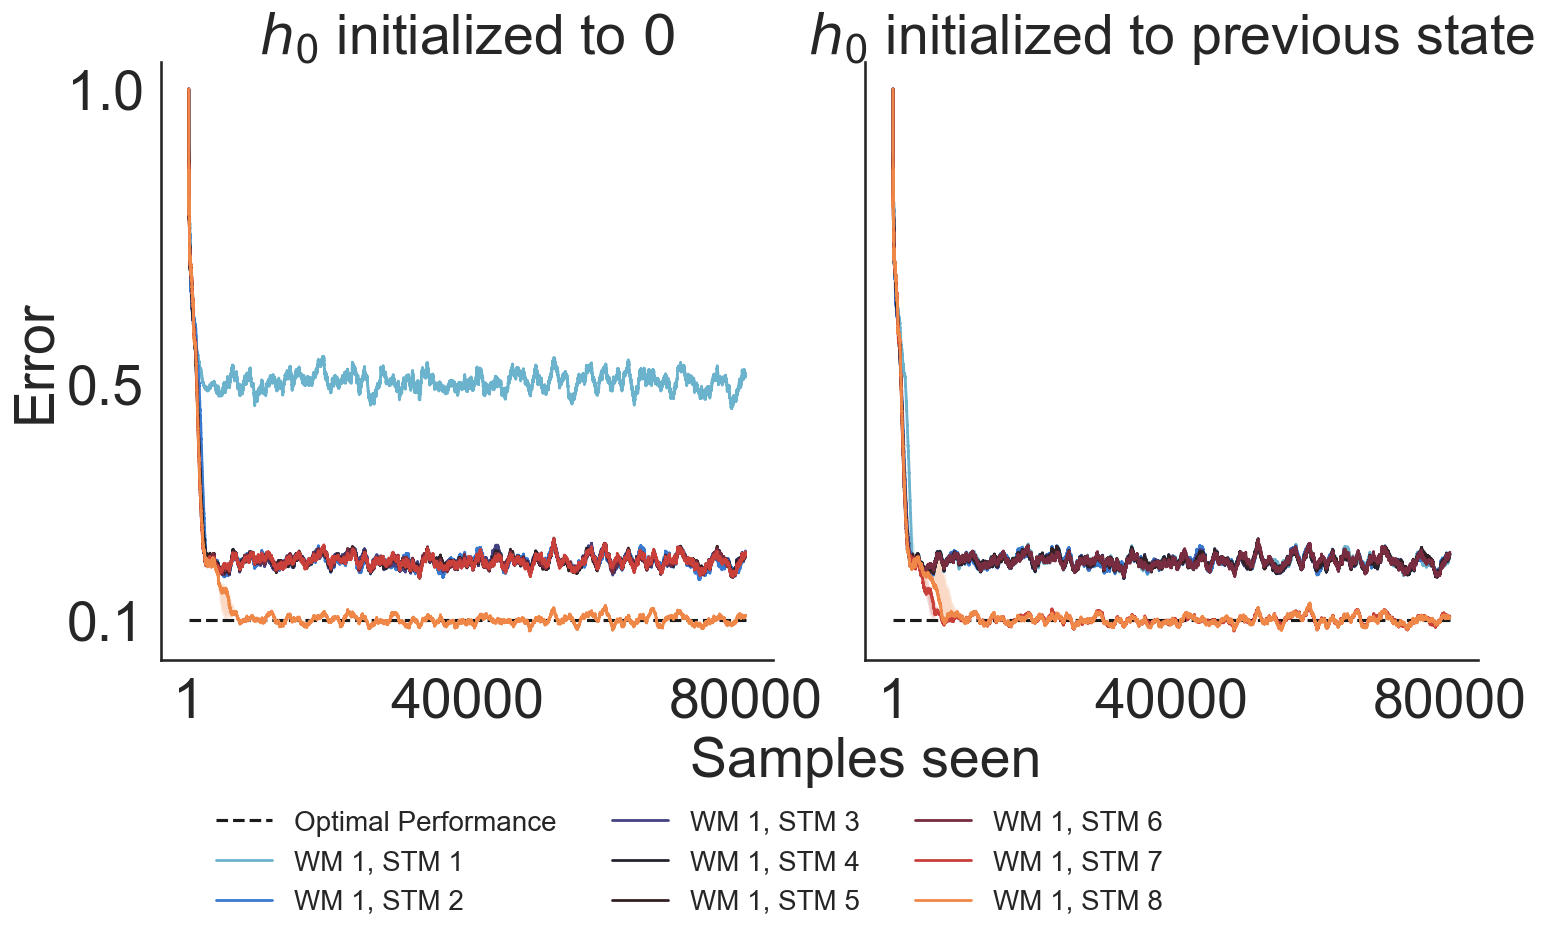

In [218]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("icefire", n_colors=len(short_term_memories))
font = 40
samples_to_show = 80000

fig, ax = plt.subplots(1, 2, figsize=(16,8), sharex=True, sharey=True)

ax[0].hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')
ax[1].hlines(0.1, 0, samples_to_show, linestyles='dashed', color='k')

for ii, short_term_memory in enumerate(short_term_memories):
    ax[1].plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_with_mem[ii][:,:samples_to_show],axis=0),linewidth=2, c=clr[ii])
    ax[1].fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_with_mem[ii][:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_with_mem[ii][:,:samples_to_show], 0.75, axis=0), facecolor=clr[ii], alpha=.3)

    ax[0].plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_without_mem[ii][:,:samples_to_show],axis=0),linewidth=2, c=clr[ii], label='WM '+str(working_memory)+', STM '+str(short_term_memory))
    ax[0].fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_without_mem[ii][:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_without_mem[ii][:,:samples_to_show], 0.75, axis=0), facecolor=clr[ii], alpha=.3)


plt.xticks([1, samples_to_show//2, samples_to_show])
plt.yticks([0.1, 0.5, 1.0])

ax[0].set_ylabel('Error', fontsize=font)



for ii in range(2):
    ax[ii].tick_params(labelsize=40)
    
    right_side = ax[ii].spines["right"]
    right_side.set_visible(False)
    top_side = ax[ii].spines["top"]
    top_side.set_visible(False)

ax[0].set_title(r"$h_0$ initialized to $0$", fontsize=font)
ax[1].set_title(r"$h_0$ initialized to previous state", fontsize=font)

fig.legend(bbox_to_anchor=(0.45, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=3, loc='upper center', fontsize=20, frameon=False)

fig.text(0.45, -.01, 'Samples seen', fontsize=font)

plt.tight_layout()


In [10]:
import pickle

with open('store_res.pickle','rb') as f:
    (test_acc_without_mem, test_acc_with_mem) = pickle.load(f)

(test_acc_without_mem, test_acc_with_mem) = (np.array(test_acc_without_mem), np.array(test_acc_with_mem))

In [23]:
test_err_without_mem_mean = np.mean(1-test_acc_without_mem[:,:,:80000],axis=1)
test_err_without_mem_std = np.std(1-test_acc_without_mem[:,:,:80000],axis=1)
test_err_with_mem_mean = np.mean(1-test_acc_with_mem[:,:,:80000],axis=1)
test_err_with_mem_std = np.std(1-test_acc_with_mem[:,:,:80000],axis=1)

print(np.min(test_err_with_mem_mean, axis=1), np.argmin(test_err_with_mem_mean, axis=1))
print(np.min(test_err_without_mem_mean, axis=1), np.argmin(test_err_without_mem_mean, axis=1))

[0.1702 0.1742 0.1718 0.1716 0.172  0.1724 0.0816 0.0812] [33106 77941 33179 33178 78167 33097 48965 55794]
[0.4584 0.1682 0.1762 0.1718 0.1708 0.1718 0.1718 0.0814] [78004 73311 33190 33178 78167 78166 33096 48954]


### <center> with $h_0$ initialized to zero </center>

| WM | STM    | min error | min sample to reach min err |
| :-----| :-----| :-----: | :-----: |
| 1     | 1     | 0.46    | 78004   |
| 1     | 2     | 0.17    | 73311   |
| 1     | 3     | 0.18    | 33190   |
| 1     | 4     | 0.17    | 33178   |
| 1     | 5     | 0.17    | 78167   |
| 1     | 6     | 0.17    | 78166   |
| 1     | 7     | 0.17    | 33096   |
| 1     | 8     | 0.08    | 48954   |



<br>
<br>

### <center> with $h_0$ initialized to previous state </center>

| WM | STM    | min error | min sample to reach min err |
| :-----| :-----| :-----: | :-----: |
| 1     | 1     | 0.17    | 33106   |
| 1     | 2     | 0.17    | 77941   |
| 1     | 3     | 0.17    | 33179   |
| 1     | 4     | 0.17    | 33178   |
| 1     | 5     | 0.17    | 78167   |
| 1     | 6     | 0.17    | 33097   |
| 1     | 7     | 0.08    | 48965   |
| 1     | 8     | 0.08    | 55794   |




In [219]:
import pickle
summary = (test_acc_without_mem, test_acc_with_mem)

with open('store_res.pickle','wb') as f:
    pickle.dump(summary, f)

In [220]:
def experiment_sleep(working_memory, short_term_memory, dropping_proba=0.1, first_training=200, compressed_training=1000, hidden_size=128, num_layers=1, reps=5, lr=1e-3, prev_mem=False):
    test_acc_rnn = np.zeros((reps, len(data[:500000])-1), dtype=float)
    data_set = Dataset_converter_compressed(data[:500000], dropping_proba, first_training, compressed_training, working_memory, short_term_memory)
    
    for rep in tqdm(range(reps)):
        torch.manual_seed(rep)
        model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
        
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = torch.nn.CrossEntropyLoss()
    
        total = 0
        correct = np.zeros(1000,dtype=float)
        for X, y in train_loader:
            optimizer.zero_grad()
    
            if total==0:
                    # print(hidden_memory.shape)
                predicted_y, _ = model(X)
            elif prev_mem:
                    
                predicted_y, _ = model(X, mem)
            else:
                predicted_y, _ = model(X)

            # print(predicted_y.shape, y.shape)
            loss = criterion(predicted_y, y)
            loss.backward()
    
            optimizer.step()
    
            with torch.no_grad():
                
                if prev_mem:
                     _, mem = model(X[:1,:1,:], return_state_only=True)

                
                true_y = y.argmax(axis=1)
                estimated_y = predicted_y.argmax(axis=1)

                if true_y == estimated_y:
                        correct[total%1000] = 1
                else:
                    correct[total%1000] = 0

                total += 1
                test_acc_rnn[rep,total] = np.sum(correct)/total if total<1000 else np.sum(correct)/1000
                
                    
    
                if total%1000 == 0:
                    print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc_rnn[rep,total-1]:.4f}')

    
    return test_acc_rnn

# Working memory 1 and short term memory 3

In [221]:
working_memory = 1
short_term_memory = 6
dropping_probas = [0.25]
first_training = 1000
compressed_training = 10000
test_acc = []

for dropping_proba in dropping_probas:
    print('Doing proba ', dropping_proba)
    
    test_acc.append(
        experiment_sleep(working_memory, short_term_memory, dropping_proba, first_training, compressed_training, prev_mem=True)
    )


Doing proba  0.25


  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1001, loss: 0.0243, accuracy: 0.5355
Iter : 2001, loss: 1.3846, accuracy: 0.5920
Iter : 3001, loss: 0.1580, accuracy: 0.6900
Iter : 4001, loss: 1.1989, accuracy: 0.6860
Iter : 5001, loss: 1.3146, accuracy: 0.6730
Iter : 6001, loss: 0.3609, accuracy: 0.6540
Iter : 7001, loss: 1.5303, accuracy: 0.6720
Iter : 8001, loss: 0.1917, accuracy: 0.6580
Iter : 9001, loss: 1.6582, accuracy: 0.6840
Iter : 10001, loss: 1.7114, accuracy: 0.7140
Iter : 11001, loss: 0.5921, accuracy: 0.7950
Iter : 12001, loss: 1.3050, accuracy: 0.8010
Iter : 13001, loss: 0.3841, accuracy: 0.7980
Iter : 14001, loss: 0.7737, accuracy: 0.7890
Iter : 15001, loss: 0.3745, accuracy: 0.8040
Iter : 16001, loss: 0.4644, accuracy: 0.8050
Iter : 17001, loss: 0.9811, accuracy: 0.7990
Iter : 18001, loss: 0.9263, accuracy: 0.7870
Iter : 19001, loss: 0.6212, accuracy: 0.8060
Iter : 20001, loss: 0.7093, accuracy: 0.7980
Iter : 21001, loss: 0.9351, accuracy: 0.8000
Iter : 22001, loss: 0.5121, accuracy: 0.7960
Iter : 23001, loss:

 20%|████████████████████████████                                                                                                                | 1/5 [00:51<03:27, 51.94s/it]

Iter : 1001, loss: 0.0181, accuracy: 0.4975
Iter : 2001, loss: 1.3224, accuracy: 0.6010
Iter : 3001, loss: 0.1636, accuracy: 0.6720
Iter : 4001, loss: 1.2395, accuracy: 0.6890
Iter : 5001, loss: 1.3747, accuracy: 0.6750
Iter : 6001, loss: 0.3591, accuracy: 0.6540
Iter : 7001, loss: 1.5319, accuracy: 0.6720
Iter : 8001, loss: 0.2055, accuracy: 0.6600
Iter : 9001, loss: 1.6886, accuracy: 0.6800
Iter : 10001, loss: 1.6833, accuracy: 0.7120
Iter : 11001, loss: 0.6002, accuracy: 0.7980
Iter : 12001, loss: 1.3451, accuracy: 0.8030
Iter : 13001, loss: 0.3816, accuracy: 0.7980
Iter : 14001, loss: 0.7665, accuracy: 0.7910
Iter : 15001, loss: 0.3739, accuracy: 0.8010
Iter : 16001, loss: 0.4647, accuracy: 0.8040
Iter : 17001, loss: 0.9839, accuracy: 0.8020
Iter : 18001, loss: 0.9286, accuracy: 0.7840
Iter : 19001, loss: 0.6093, accuracy: 0.8030
Iter : 20001, loss: 0.7140, accuracy: 0.7970
Iter : 21001, loss: 0.9386, accuracy: 0.8010
Iter : 22001, loss: 0.5127, accuracy: 0.7930
Iter : 23001, loss:

...

 60%|████████████████████████████████████████████████████████████████████████████████████                                                        | 3/5 [02:32<01:41, 50.61s/it]

Iter : 1001, loss: 0.0176, accuracy: 0.5095
Iter : 2001, loss: 1.3617, accuracy: 0.5950
Iter : 3001, loss: 0.1490, accuracy: 0.6790
Iter : 4001, loss: 1.2503, accuracy: 0.6890
Iter : 5001, loss: 1.3488, accuracy: 0.6780
Iter : 6001, loss: 0.3509, accuracy: 0.6560
Iter : 7001, loss: 1.5420, accuracy: 0.6770
Iter : 8001, loss: 0.1882, accuracy: 0.6550
Iter : 9001, loss: 1.7490, accuracy: 0.6810
Iter : 10001, loss: 1.7434, accuracy: 0.7130
Iter : 11001, loss: 0.5903, accuracy: 0.7960
Iter : 12001, loss: 1.3038, accuracy: 0.8020
Iter : 13001, loss: 0.3910, accuracy: 0.7990
Iter : 14001, loss: 0.7804, accuracy: 0.7890
Iter : 15001, loss: 0.3825, accuracy: 0.8040
Iter : 16001, loss: 0.4721, accuracy: 0.8030
Iter : 17001, loss: 0.9921, accuracy: 0.8020
Iter : 18001, loss: 0.9221, accuracy: 0.7900
Iter : 19001, loss: 0.6222, accuracy: 0.8040
Iter : 20001, loss: 0.7024, accuracy: 0.8020
Iter : 21001, loss: 0.9345, accuracy: 0.8030
Iter : 22001, loss: 0.5254, accuracy: 0.7920
Iter : 23001, loss:

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████                            | 4/5 [03:22<00:50, 50.54s/it]

Iter : 1001, loss: 0.0174, accuracy: 0.4905
Iter : 2001, loss: 1.2451, accuracy: 0.5920
Iter : 3001, loss: 0.1618, accuracy: 0.6780
Iter : 4001, loss: 1.1574, accuracy: 0.6810
Iter : 5001, loss: 1.4181, accuracy: 0.6750
Iter : 6001, loss: 0.3383, accuracy: 0.6610
Iter : 7001, loss: 1.5410, accuracy: 0.6810
Iter : 8001, loss: 0.1842, accuracy: 0.6560
Iter : 9001, loss: 1.6446, accuracy: 0.6790
Iter : 10001, loss: 1.6531, accuracy: 0.7160
Iter : 11001, loss: 0.5824, accuracy: 0.7970
Iter : 12001, loss: 1.3155, accuracy: 0.8040
Iter : 13001, loss: 0.3812, accuracy: 0.7940
Iter : 14001, loss: 0.7477, accuracy: 0.7910
Iter : 15001, loss: 0.3802, accuracy: 0.8030
Iter : 16001, loss: 0.4630, accuracy: 0.8030
Iter : 17001, loss: 0.9357, accuracy: 0.7970
Iter : 18001, loss: 0.9168, accuracy: 0.7850
Iter : 19001, loss: 0.6048, accuracy: 0.8030
Iter : 20001, loss: 0.6805, accuracy: 0.8010
Iter : 21001, loss: 0.9014, accuracy: 0.8010
Iter : 22001, loss: 0.5407, accuracy: 0.7960
Iter : 23001, loss:

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:12<00:00, 50.57s/it]


In [ ]:
sleeping_time_start = first_training
sleeping_time_end = first_training+compressed_training
samples_to_show = 50000

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("tab10", n_colors=7)
font = 40
samples_to_show = 300000

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

for ii, dropping_proba in enumerate(dropping_probas):
    acc = test_acc[ii][:][:samples_to_show]
    
    ax.plot(np.arange(1,sleeping_time_start+1), np.median(1-acc[:,:sleeping_time_start],axis=0),linewidth=2, c=clr[ii], label='dropping proba '+str(dropping_proba))
    # ax.fill_between(np.arange(1,sleeping_time_start+1), np.quantile(1-acc[:,:sleeping_time_start], 0.25, axis=0), np.quantile(1-acc[:,:sleeping_time_start], 0.75, axis=0), facecolor=clr[ii], alpha=.3)

    ax.plot(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.median(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1],axis=0), linewidth=2, c=clr[ii])
    # ax.fill_between(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.25, axis=0), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.75, axis=0), facecolor=clr[ii], alpha=.3)


ax.hlines(0.1, 0, samples_to_show+10000, linestyles='dashed', label='Optimal Performance', color='k')
ax.vlines(sleeping_time_start, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(sleeping_time_start+sleeping_time_end, 0.1, 1, linestyles='dashed', color='b')

plt.xticks([1, samples_to_show//2, samples_to_show])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)



ax.tick_params(labelsize=40)

right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)



fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)

fig.text(.26, .92, 'Sleep', rotation=0, fontsize=20)
fig.text(0.45, -.01, 'Samples seen', fontsize=font)

plt.tight_layout()


# Working memory 1 and short term memory 20

In [197]:
working_memory = 1
short_term_memory = 20
dropping_probas = [0.0,0.1,0.2,0.3,0.4,0.5,0.6]
first_training = 10000
compressed_training = 20000
test_acc = []

for dropping_proba in dropping_probas:
    print('Doing proba ', dropping_proba)
    
    test_acc.append(
        experiment_sleep(working_memory, short_term_memory, dropping_proba, first_training, compressed_training, prev_mem=True)
    )


Doing proba  0.0


  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1001, loss: 0.4656, accuracy: 0.5265
Iter : 2001, loss: 0.0564, accuracy: 0.7630
Iter : 3001, loss: 0.0296, accuracy: 0.7930
Iter : 4001, loss: 0.0167, accuracy: 0.8130
Iter : 5001, loss: 0.0132, accuracy: 0.8040
Iter : 6001, loss: 0.0226, accuracy: 0.8070
Iter : 7001, loss: 0.0514, accuracy: 0.7980
Iter : 8001, loss: 0.0109, accuracy: 0.8190
Iter : 9001, loss: 0.0177, accuracy: 0.8740
Iter : 10001, loss: 0.0161, accuracy: 0.9000
Iter : 11001, loss: 0.0161, accuracy: 0.9020


  0%|                                                                                                                                                    | 0/5 [00:11<?, ?it/s]


KeyboardInterrupt: 

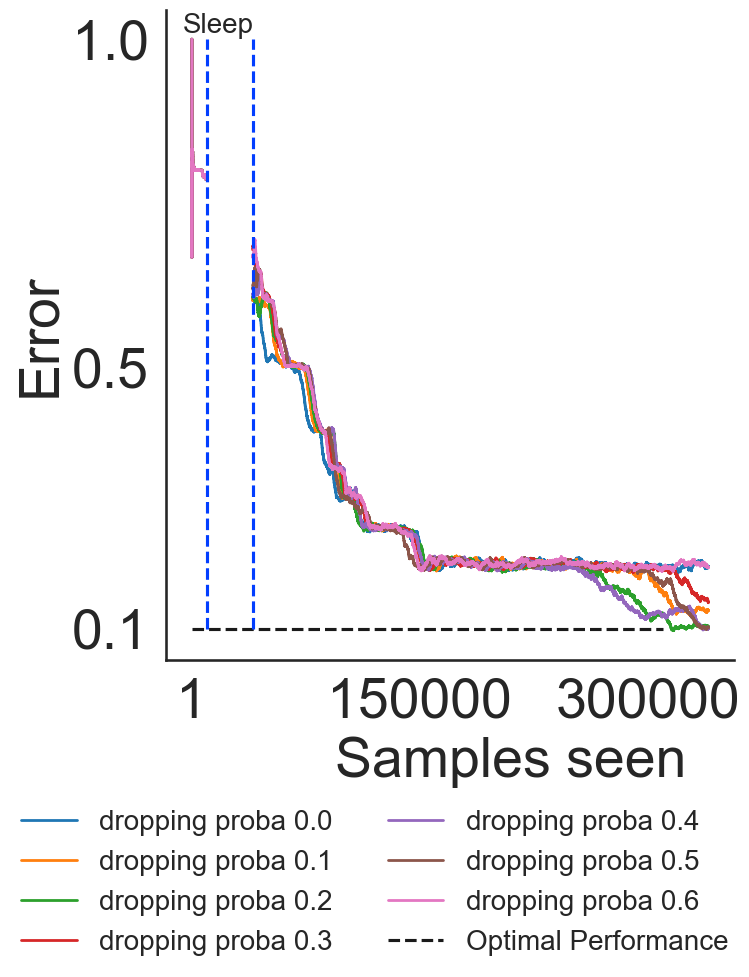

In [601]:
sleeping_time_start = first_training
sleeping_time_end = first_training+compressed_training
samples_to_show = 50000

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("tab10", n_colors=7)
font = 40
samples_to_show = 300000

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

for ii, dropping_proba in enumerate(dropping_probas):
    acc = test_acc[ii][:][:samples_to_show]
    
    ax.plot(np.arange(1,sleeping_time_start+1), np.median(1-acc[:,:sleeping_time_start],axis=0),linewidth=2, c=clr[ii], label='dropping proba '+str(dropping_proba))
    # ax.fill_between(np.arange(1,sleeping_time_start+1), np.quantile(1-acc[:,:sleeping_time_start], 0.25, axis=0), np.quantile(1-acc[:,:sleeping_time_start], 0.75, axis=0), facecolor=clr[ii], alpha=.3)

    ax.plot(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.median(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1],axis=0), linewidth=2, c=clr[ii])
    # ax.fill_between(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.25, axis=0), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.75, axis=0), facecolor=clr[ii], alpha=.3)


ax.hlines(0.1, 0, samples_to_show+10000, linestyles='dashed', label='Optimal Performance', color='k')
ax.vlines(sleeping_time_start, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(sleeping_time_start+sleeping_time_end, 0.1, 1, linestyles='dashed', color='b')

plt.xticks([1, samples_to_show//2, samples_to_show])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)



ax.tick_params(labelsize=40)

right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)



fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)

fig.text(.26, .92, 'Sleep', rotation=0, fontsize=20)
fig.text(0.45, -.01, 'Samples seen', fontsize=font)

plt.tight_layout()


# Working memory 1 and short term memory 1

In [602]:
working_memory = 1
short_term_memory = 1
dropping_probas = [0.0,0.1,0.2,0.3,0.4,0.5,0.6]
first_training = 10000
compressed_training = 20000
test_acc = []

for dropping_proba in dropping_probas:
    print('Doing proba ', dropping_proba)
    
    test_acc.append(
        experiment_sleep(working_memory, short_term_memory, dropping_proba, first_training, compressed_training, prev_mem=True)
    )


Doing proba  0.0


  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1212, accuracy: 0.0000
Iter : 1001, loss: 0.1091, accuracy: 0.2058
Iter : 2001, loss: 0.0933, accuracy: 0.2134
Iter : 3001, loss: 0.0858, accuracy: 0.2749
Iter : 4001, loss: 0.0822, accuracy: 0.3254
Iter : 5001, loss: 0.0346, accuracy: 0.3702
Iter : 6001, loss: 0.1062, accuracy: 0.4624
Iter : 7001, loss: 0.0972, accuracy: 0.5636
Iter : 8001, loss: 0.0085, accuracy: 0.6336
Iter : 9001, loss: 0.1286, accuracy: 0.6906
Iter : 10001, loss: 0.1030, accuracy: 0.7362
Iter : 11001, loss: 0.0204, accuracy: 0.7612
Iter : 12001, loss: 0.0675, accuracy: 0.7740
Iter : 13001, loss: 0.0026, accuracy: 0.7868
Iter : 14001, loss: 0.0845, accuracy: 0.7922
Iter : 15001, loss: 0.1583, accuracy: 0.7974
Iter : 16001, loss: 0.0179, accuracy: 0.7964
Iter : 17001, loss: 0.1022, accuracy: 0.8002
Iter : 18001, loss: 0.1257, accuracy: 0.7968
Iter : 19001, loss: 0.0766, accuracy: 0.7962
Iter : 20001, loss: 0.0837, accuracy: 0.7928
Iter : 21001, loss: 0.1659, accuracy: 0.7964
Iter : 22001, loss: 0.0

 20%|███████████████████████████▊                                                                                                               | 1/5 [02:34<10:16, 154.06s/it]

Iter : 1, loss: 0.1159, accuracy: 1.0000
Iter : 1001, loss: 0.1095, accuracy: 0.2388
Iter : 2001, loss: 0.0647, accuracy: 0.3158
Iter : 3001, loss: 0.1085, accuracy: 0.3589
Iter : 4001, loss: 0.0918, accuracy: 0.4216
Iter : 5001, loss: 0.0374, accuracy: 0.4838
Iter : 6001, loss: 0.0977, accuracy: 0.5950
Iter : 7001, loss: 0.1361, accuracy: 0.6732
Iter : 8001, loss: 0.0093, accuracy: 0.7438
Iter : 9001, loss: 0.1095, accuracy: 0.7812
Iter : 10001, loss: 0.1218, accuracy: 0.7942
Iter : 11001, loss: 0.0321, accuracy: 0.7964
Iter : 12001, loss: 0.0652, accuracy: 0.7988
Iter : 13001, loss: 0.0203, accuracy: 0.8022
Iter : 14001, loss: 0.0738, accuracy: 0.8028
Iter : 15001, loss: 0.0896, accuracy: 0.8036
Iter : 16001, loss: 0.0515, accuracy: 0.7998
Iter : 17001, loss: 0.0914, accuracy: 0.8014
Iter : 18001, loss: 0.0851, accuracy: 0.7984
Iter : 19001, loss: 0.0780, accuracy: 0.7954
Iter : 20001, loss: 0.0747, accuracy: 0.7940
Iter : 21001, loss: 0.0906, accuracy: 0.7970
Iter : 22001, loss: 0.0

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [07:26<04:57, 148.80s/it]

Iter : 1, loss: 0.1104, accuracy: 1.0000
Iter : 1001, loss: 0.1061, accuracy: 0.2118
Iter : 2001, loss: 0.1057, accuracy: 0.2369
Iter : 3001, loss: 0.0919, accuracy: 0.2826
Iter : 4001, loss: 0.0857, accuracy: 0.3179
Iter : 5001, loss: 0.0640, accuracy: 0.3540
Iter : 6001, loss: 0.0971, accuracy: 0.4234
Iter : 7001, loss: 0.1278, accuracy: 0.5030
Iter : 8001, loss: 0.0150, accuracy: 0.5746
Iter : 9001, loss: 0.1232, accuracy: 0.6474
Iter : 10001, loss: 0.1381, accuracy: 0.7070
Iter : 11001, loss: 0.0390, accuracy: 0.6492
Iter : 12001, loss: 0.1712, accuracy: 0.5728
Iter : 13001, loss: 0.1205, accuracy: 0.4910
Iter : 14001, loss: 0.1684, accuracy: 0.3984
Iter : 15001, loss: 0.1183, accuracy: 0.3044
Iter : 16001, loss: 0.1728, accuracy: 0.3130
Iter : 17001, loss: 0.0674, accuracy: 0.3132
Iter : 18001, loss: 0.0729, accuracy: 0.3160
Iter : 19001, loss: 0.0274, accuracy: 0.3858
Iter : 20001, loss: 0.0050, accuracy: 0.4816
Iter : 21001, loss: 0.0004, accuracy: 0.5822
Iter : 22001, loss: 0.0

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [09:54<02:28, 148.76s/it]

Iter : 1, loss: 0.1380, accuracy: 0.0000
Iter : 1001, loss: 0.1267, accuracy: 0.1998
Iter : 2001, loss: 0.0790, accuracy: 0.2664
Iter : 3001, loss: 0.1309, accuracy: 0.3159
Iter : 4001, loss: 0.0647, accuracy: 0.3644
Iter : 5001, loss: 0.0332, accuracy: 0.4044
Iter : 6001, loss: 0.0976, accuracy: 0.4928
Iter : 7001, loss: 0.1101, accuracy: 0.5752
Iter : 8001, loss: 0.0253, accuracy: 0.6430
Iter : 9001, loss: 0.1472, accuracy: 0.6994
Iter : 10001, loss: 0.1182, accuracy: 0.7484
Iter : 11001, loss: 0.0685, accuracy: 0.6782
Iter : 12001, loss: 0.1337, accuracy: 0.5846
Iter : 13001, loss: 0.1727, accuracy: 0.4998
Iter : 14001, loss: 0.0777, accuracy: 0.4030
Iter : 15001, loss: 0.1239, accuracy: 0.3060
Iter : 16001, loss: 0.1642, accuracy: 0.3064
Iter : 17001, loss: 0.0910, accuracy: 0.3092
Iter : 18001, loss: 0.0687, accuracy: 0.3112
Iter : 19001, loss: 0.0115, accuracy: 0.3934
Iter : 20001, loss: 0.0036, accuracy: 0.4900
Iter : 21001, loss: 0.0003, accuracy: 0.5948
Iter : 22001, loss: 0.0

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [12:23<00:00, 148.75s/it]


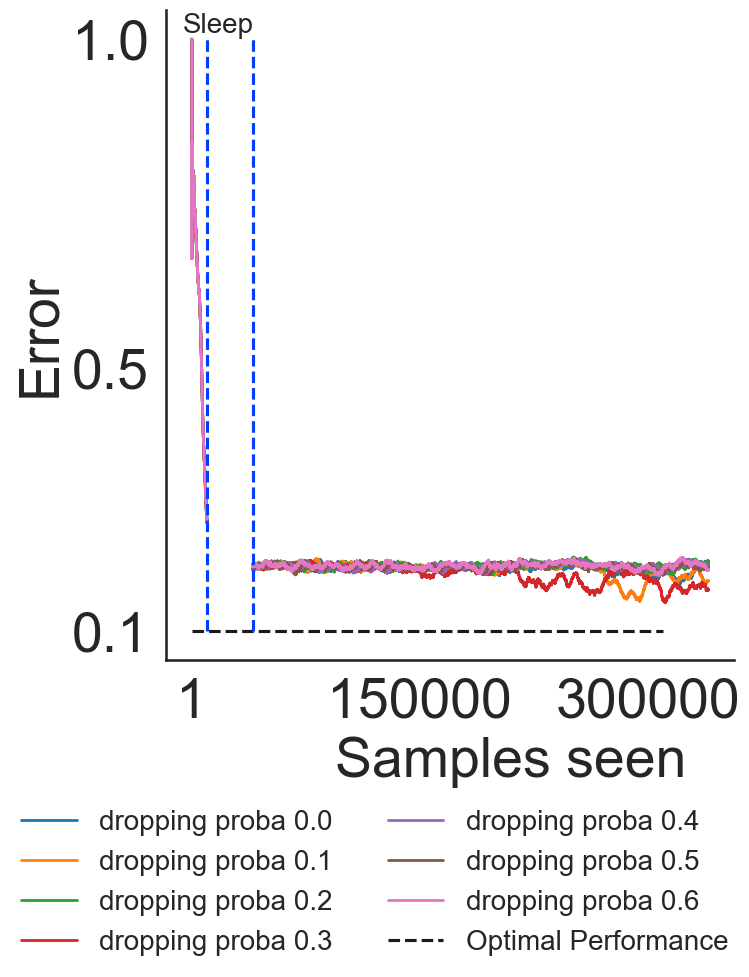

In [605]:
sleeping_time_start = first_training
sleeping_time_end = first_training+compressed_training
samples_to_show = 50000

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("tab10", n_colors=7)
font = 40
samples_to_show = 300000

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

for ii, dropping_proba in enumerate(dropping_probas):
    acc = test_acc[ii][:][:samples_to_show]
    
    ax.plot(np.arange(1,sleeping_time_start+1), np.median(1-acc[:,:sleeping_time_start],axis=0),linewidth=2, c=clr[ii], label='dropping proba '+str(dropping_proba))
    # ax.fill_between(np.arange(1,sleeping_time_start+1), np.quantile(1-acc[:,:sleeping_time_start], 0.25, axis=0), np.quantile(1-acc[:,:sleeping_time_start], 0.75, axis=0), facecolor=clr[ii], alpha=.3)

    ax.plot(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.median(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1],axis=0), linewidth=2, c=clr[ii])
    # ax.fill_between(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.25, axis=0), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.75, axis=0), facecolor=clr[ii], alpha=.3)


ax.hlines(0.1, 0, samples_to_show+10000, linestyles='dashed', label='Optimal Performance', color='k')
ax.vlines(sleeping_time_start, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(sleeping_time_start+sleeping_time_end, 0.1, 1, linestyles='dashed', color='b')

plt.xticks([1, samples_to_show//2, samples_to_show])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)



ax.tick_params(labelsize=40)

right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)



fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)

fig.text(.26, .92, 'Sleep', rotation=0, fontsize=20)
fig.text(0.45, -.01, 'Samples seen', fontsize=font)

plt.tight_layout()


# Define functions to generate more complicated sequence

In [75]:
def _get_member(community, n_members, clockwise=True):
    seq = chr(community*n_members + ord('A'))
    
    if clockwise:
        next_token = chr(community*n_members + ord('A') + 1)
    else:
        next_token = chr(community*n_members + ord('A') + n_members-1)

    for _ in range(n_members-1):
        seq += next_token

        if clockwise:
            next_token = chr(ord(next_token) + 1)
        else:
            next_token = chr(ord(next_token) - 1)

    seq += seq[0]
    return seq 

def get_sequence(n_samples, n_community, n_members, random_state=0):
    
    """
    Generate data sequence divided into communities.

    Parameters
    ----------
    n_samples : int
        Total number of tokens to sample.
    n_community : int
        Total number of community.
    n_members : int
        Total number of members in each community.
    random_state : int, RandomState instance, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    out : array of shape [n_samples]
        The generated sequence of tokens.
    """

    if random_state != None:
        np.random.seed(random_state)

    visits = []
    direction = []
    total_community_visit = int(np.ceil(n_samples/n_members))
    
    for ii in range(total_community_visit):
        visits.append(
            np.random.choice(n_community)
        )

        if ii == 0 or ii == 1:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] == visits[-1]:
            direction.append(False)
        elif visits[-2] != visits[-1] and visits[-3] == visits[-1]:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] != visits[-1]:
            direction.append(True)
        else:
            direction.append(False)

    out = ''
    for ii, community in enumerate(visits):
        out += _get_member(community, n_members, clockwise=direction[ii]) + chr(ord('A')+n_community*n_members)

    return out[:n_samples]
        

In [129]:
total_length = 1000000
n_community = 2
n_members = 3
tokens = []

for ii in range(n_community):
    for jj in range(n_members):
        tokens.append(
            chr(ord('A')+ii*n_members+jj)
        )

tokens.append(
            chr(ord(tokens[-1])+1)
        )
data = get_sequence(total_length, n_community, n_members)

working_memory = 1
short_term_memory = 20
dropping_probas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
first_training = 10000
compressed_training = 20000
test_acc = []

for dropping_proba in dropping_probas:
    print('Doing proba ', dropping_proba)
    
    test_acc.append(
        experiment_sleep(working_memory, short_term_memory, dropping_proba, first_training, compressed_training, prev_mem=False)
    )

Doing proba  0.0


  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1254, accuracy: 0.1000
Iter : 1001, loss: 0.1201, accuracy: 0.2006
Iter : 2001, loss: 0.1140, accuracy: 0.3024
Iter : 3001, loss: 0.0989, accuracy: 0.3966
Iter : 4001, loss: 0.0656, accuracy: 0.5484
Iter : 5001, loss: 0.0645, accuracy: 0.5872
Iter : 6001, loss: 0.0553, accuracy: 0.6634
Iter : 7001, loss: 0.0555, accuracy: 0.7178
Iter : 8001, loss: 0.0463, accuracy: 0.7540
Iter : 9001, loss: 0.0388, accuracy: 0.7524
Iter : 10001, loss: 0.0364, accuracy: 0.8008
Iter : 11001, loss: 0.0365, accuracy: 0.7984
Iter : 12001, loss: 0.0303, accuracy: 0.8070
Iter : 13001, loss: 0.0299, accuracy: 0.8018
Iter : 14001, loss: 0.0308, accuracy: 0.8076
Iter : 15001, loss: 0.0356, accuracy: 0.7954
Iter : 16001, loss: 0.0272, accuracy: 0.8002
Iter : 17001, loss: 0.0338, accuracy: 0.7988
Iter : 18001, loss: 0.0296, accuracy: 0.8070
Iter : 19001, loss: 0.0272, accuracy: 0.7996
Iter : 20001, loss: 0.0279, accuracy: 0.8096
Iter : 21001, loss: 0.0312, accuracy: 0.8032
Iter : 22001, loss: 0.0

 20%|████████████████████████████                                                                                                                | 1/5 [00:53<03:34, 53.64s/it]

Iter : 1, loss: 0.1223, accuracy: 0.1000
Iter : 1001, loss: 0.1179, accuracy: 0.3968
Iter : 2001, loss: 0.1044, accuracy: 0.4962
Iter : 3001, loss: 0.0702, accuracy: 0.5098
Iter : 4001, loss: 0.0556, accuracy: 0.6930
Iter : 5001, loss: 0.0482, accuracy: 0.7378
Iter : 6001, loss: 0.0398, accuracy: 0.7498
Iter : 7001, loss: 0.0348, accuracy: 0.8004
Iter : 8001, loss: 0.0338, accuracy: 0.8010
Iter : 9001, loss: 0.0293, accuracy: 0.7978
Iter : 10001, loss: 0.0289, accuracy: 0.8212
Iter : 11001, loss: 0.0281, accuracy: 0.8342
Iter : 12001, loss: 0.0231, accuracy: 0.8560
Iter : 13001, loss: 0.0222, accuracy: 0.8492
Iter : 14001, loss: 0.0253, accuracy: 0.8518
Iter : 15001, loss: 0.0312, accuracy: 0.8466
Iter : 16001, loss: 0.0201, accuracy: 0.8460
Iter : 17001, loss: 0.0284, accuracy: 0.8468
Iter : 18001, loss: 0.0217, accuracy: 0.8458
Iter : 19001, loss: 0.0194, accuracy: 0.8504
Iter : 20001, loss: 0.0194, accuracy: 0.8482
Iter : 21001, loss: 0.0226, accuracy: 0.8522
Iter : 22001, loss: 0.0

...

 60%|████████████████████████████████████████████████████████████████████████████████████                                                        | 3/5 [02:38<01:45, 52.87s/it]

Iter : 1, loss: 0.1260, accuracy: 0.1000
Iter : 1001, loss: 0.1199, accuracy: 0.2466
Iter : 2001, loss: 0.1184, accuracy: 0.3404
Iter : 3001, loss: 0.1149, accuracy: 0.2992
Iter : 4001, loss: 0.0886, accuracy: 0.4348
Iter : 5001, loss: 0.0625, accuracy: 0.6128
Iter : 6001, loss: 0.0554, accuracy: 0.6632
Iter : 7001, loss: 0.0497, accuracy: 0.6992
Iter : 8001, loss: 0.0450, accuracy: 0.7046
Iter : 9001, loss: 0.0412, accuracy: 0.7544
Iter : 10001, loss: 0.0404, accuracy: 0.8002
Iter : 11001, loss: 0.0354, accuracy: 0.8082
Iter : 12001, loss: 0.0297, accuracy: 0.8004
Iter : 13001, loss: 0.0304, accuracy: 0.8008
Iter : 14001, loss: 0.0271, accuracy: 0.8002
Iter : 15001, loss: 0.0327, accuracy: 0.8028
Iter : 16001, loss: 0.0312, accuracy: 0.7998
Iter : 17001, loss: 0.0284, accuracy: 0.7974
Iter : 18001, loss: 0.0260, accuracy: 0.7954
Iter : 19001, loss: 0.0289, accuracy: 0.7940
Iter : 20001, loss: 0.0328, accuracy: 0.7950
Iter : 21001, loss: 0.0284, accuracy: 0.8060
Iter : 22001, loss: 0.0

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████                            | 4/5 [03:31<00:52, 52.85s/it]

Iter : 1, loss: 0.1205, accuracy: 0.2000
Iter : 1001, loss: 0.1193, accuracy: 0.2358
Iter : 2001, loss: 0.1171, accuracy: 0.4042
Iter : 3001, loss: 0.1006, accuracy: 0.4330
Iter : 4001, loss: 0.0738, accuracy: 0.5084
Iter : 5001, loss: 0.0551, accuracy: 0.6884
Iter : 6001, loss: 0.0494, accuracy: 0.7390
Iter : 7001, loss: 0.0382, accuracy: 0.7870
Iter : 8001, loss: 0.0348, accuracy: 0.7992
Iter : 9001, loss: 0.0295, accuracy: 0.8044
Iter : 10001, loss: 0.0335, accuracy: 0.7986
Iter : 11001, loss: 0.0321, accuracy: 0.8078
Iter : 12001, loss: 0.0290, accuracy: 0.8056
Iter : 13001, loss: 0.0340, accuracy: 0.8064
Iter : 14001, loss: 0.0238, accuracy: 0.7964
Iter : 15001, loss: 0.0320, accuracy: 0.8006
Iter : 16001, loss: 0.0333, accuracy: 0.7978
Iter : 17001, loss: 0.0278, accuracy: 0.8034
Iter : 18001, loss: 0.0265, accuracy: 0.7986
Iter : 19001, loss: 0.0291, accuracy: 0.7884
Iter : 20001, loss: 0.0322, accuracy: 0.7922
Iter : 21001, loss: 0.0295, accuracy: 0.8082
Iter : 22001, loss: 0.0

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:24<00:00, 52.86s/it]


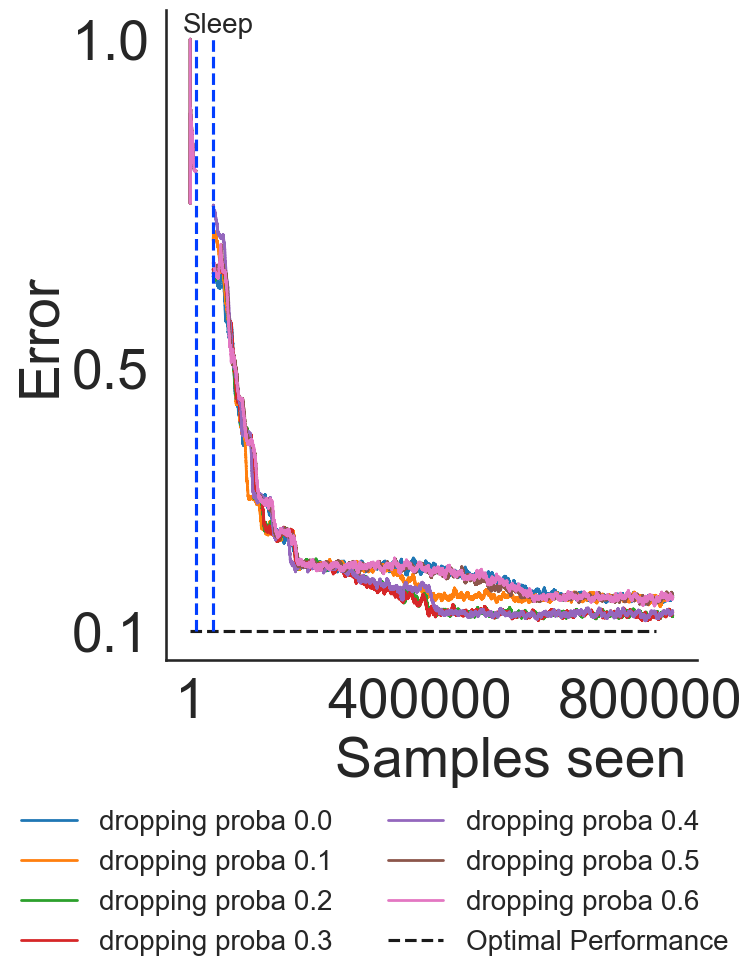

In [131]:
sleeping_time_start = first_training
sleeping_time_end = first_training+compressed_training
samples_to_show = 50000

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("tab10", n_colors=7)
font = 40
samples_to_show = 800000

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

for ii, dropping_proba in enumerate(dropping_probas):
    acc = test_acc[ii][:][:samples_to_show]
    
    ax.plot(np.arange(1,sleeping_time_start+1), np.median(1-acc[:,:sleeping_time_start],axis=0),linewidth=2, c=clr[ii], label='dropping proba '+str(dropping_proba))
    # ax.fill_between(np.arange(1,sleeping_time_start+1), np.quantile(1-acc[:,:sleeping_time_start], 0.25, axis=0), np.quantile(1-acc[:,:sleeping_time_start], 0.75, axis=0), facecolor=clr[ii], alpha=.3)

    ax.plot(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.median(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1],axis=0), linewidth=2, c=clr[ii])
    # ax.fill_between(np.arange(sleeping_time_start+sleeping_time_end,sleeping_time_start+sleeping_time_end+samples_to_show+1), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.25, axis=0), np.quantile(1-acc[:,sleeping_time_start+sleeping_time_end:sleeping_time_start+sleeping_time_end+samples_to_show+1], 0.75, axis=0), facecolor=clr[ii], alpha=.3)


ax.hlines(0.1, 0, samples_to_show+10000, linestyles='dashed', label='Optimal Performance', color='k')
ax.vlines(sleeping_time_start, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(sleeping_time_start+sleeping_time_end, 0.1, 1, linestyles='dashed', color='b')

plt.xticks([1, samples_to_show//2, samples_to_show])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)



ax.tick_params(labelsize=40)

right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)



fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)

fig.text(.26, .92, 'Sleep', rotation=0, fontsize=20)
fig.text(0.45, -.01, 'Samples seen', fontsize=font)

plt.tight_layout()
